In [2]:
import random
import pyspiel
import numpy as np
from utils.utils import board_from_shaped_observation, piece_difference_from_tensor
import chess
from open_spiel.python import rl_environment
game = pyspiel.load_game("chess")


In [3]:
import torch
class WrappedEnv:
  def __init__(self):
    self.env = rl_environment.Environment("chess")
    self.env.reset()
    self.rewards_dict = {
    chess.PAWN: 1,
    chess.KNIGHT: 3,
    chess.BISHOP: 3,
    chess.ROOK: 5,
    chess.QUEEN: 9,
}

  def reset(self):
    return self.env.reset()

  def step(self, action):
    return self.env.step(action)
  
  def get_current_player(self):
    return self.env.get_time_step().current_player()

  def state(self):
    current_player = self.get_current_player()
    if current_player != 0 and current_player != 1:
      current_player = 1 if self.env.get_time_step().rewards[0] > 0 else 0
    return np.array(self.env.get_time_step().observations["info_state"][current_player]).reshape(20, 8, 8)
  
  def get_legal_actions(self):
    current_player = self.get_current_player()
    if current_player != 0 and current_player != 1:
      current_player = 1 if self.env.get_time_step().rewards[0] > 0 else 0
    legal_actions = self.env.get_time_step().observations["legal_actions"][current_player]
    mask = torch.zeros(4674)
    mask[legal_actions] = 1.
    return mask

  def is_done(self):
    return self.env.get_time_step().last()


In [4]:
import torch
class VectorBuffer:
  def __init__(self, size:int):
    self.size = size
    self.states = torch.zeros(size, 20, 8, 8)
    self.actions = torch.zeros(size, 4674)
    
    self.actions_taken = torch.zeros(size, 1)
    self.rewards = torch.zeros(size, 1)
    self.dones = torch.zeros(size, 1)
    self.index = 0

  def add_current(self, state, action,action_taken, reward, done):
    self.states[self.index] = state
    self.actions[self.index] = action
    self.actions_taken[self.index] = action_taken
    self.rewards[self.index] = reward
    self.dones[self.index] = done


  def update_index(self):
    self.index = (self.index + 1) % self.size

  def sample_n_steps(self, n:int):
    indices = random.randint(0, self.index-n-1)
    states = self.states[indices:indices+n]
    actions = self.actions[indices:indices+n]
    actions_taken = self.actions_taken[indices:indices+n]
    rewards = self.rewards[indices:indices+n]
    dones = self.dones[indices:indices+n]
    next_states = self.states[indices+1:indices+n+1]
    next_actions = self.actions[indices+1:indices+n+1]
    next_rewards = self.rewards[indices+1:indices+n+1]
    next_dones = self.dones[indices+1:indices+n+1]

    return states, actions, actions_taken, next_rewards-rewards, dones, next_states, next_actions, next_dones

class EnvSpawner:
  def __init__(self, num_envs:int):
    self.envs = []
    self.buffers = []
    for _ in range(num_envs):
      env = WrappedEnv()
      self.envs.append(env)
      self.buffers.append(VectorBuffer(100000))
      self.previous_actions = None
      self.previous_states = None

  def reset_all(self):
    for env in self.envs:
      env.reset()
    self.update_previous_actions()
    self.update_previous_states()

  def perform_actions(self, actions:list[list[int]]):
    for env, action in zip(self.envs, actions):
      env.step(action)

  def get_current_states(self):
    return torch.tensor(np.array([env.state() for env in self.envs],dtype=np.float32))

  def get_current_actions(self):
    return torch.tensor(np.array([env.get_legal_actions() for env in self.envs],dtype=np.float32))

  def get_previous_actions(self):
    return torch.tensor(np.array([env.previous_actions for env in self.envs],dtype=np.float32))

  def get_previous_states(self):
    return torch.tensor(np.array([env.previous_states for env in self.envs],dtype=np.float32))

  def update_previous_actions(self):
    self.previous_actions = self.get_current_actions()

  def update_previous_states(self):
    self.previous_states = self.get_current_states()

  def get_done(self):
    return torch.tensor(np.array([env.is_done() for env in self.envs]))

  def append_current_to_buffer(self,actions_taken):
    current_states = self.get_current_states()
    rewards =  piece_difference_from_tensor(self.previous_states) - piece_difference_from_tensor(current_states)
    done = self.get_done()
    for i, (state, action,action_taken, reward, done) in enumerate(zip(current_states, self.previous_actions,actions_taken, rewards, done)):
      self.buffers[i].add_current(state, action,action_taken, reward, done) 
      self.buffers[i].update_index()
      
  def get_rewards(self, color ='white'):
    current_states = self.get_current_states()
    rewards =  piece_difference_from_tensor(self.previous_states) - piece_difference_from_tensor(current_states)
    return rewards if color == 'white' else -rewards

  def sample_n_steps(self, n:int):
    buffer = self.buffers[0]
    states, actions, actions_taken, rewards, dones, next_states, next_actions, next_dones = buffer.sample_n_steps(n)
    for buffer in self.buffers[1:]:
      s, a, at, nr, d, ns, na, nd = buffer.sample_n_steps(n)
      states = torch.cat([states, s], dim=0)
      actions = torch.cat([actions, a], dim=0)
      actions_taken = torch.cat([actions_taken, at], dim=0)
      rewards = torch.cat([rewards, nr], dim=0)
      dones = torch.cat([dones, d], dim=0)
      next_states = torch.cat([next_states, ns], dim=0)
      next_actions = torch.cat([next_actions, na], dim=0)
      next_dones = torch.cat([next_dones, nd], dim=0)
    return {"states": states, "actions": actions, "actions_taken": actions_taken, "rewards": rewards, "dones": dones, "next_states": next_states, "next_actions": next_actions, "next_dones": next_dones}

  def generate_actions(self, policy, model, eps=0.05):
    current_states = self.get_current_states()
    actions = policy(model, current_states,self.get_current_actions(), eps)
    return torch.argmax(actions, dim=1).unsqueeze(1)

  def one_interation(self, actions:torch.Tensor):
    # White moves — skip envs that are already done
    self.update_previous_actions()
    self.update_previous_states()
    for env, action in zip(self.envs, actions.tolist()):
      if not env.is_done():
        env.step(action)

    # Black moves — skip envs that are now done (e.g. white just checkmated)
    for env in self.envs:
      if not env.is_done():
        legal = env.get_legal_actions().nonzero().tolist()
        env.step(random.choice(legal))

    self.append_current_to_buffer(actions)

  def move(self, actions:torch.Tensor):
    for env, action in zip(self.envs, actions.tolist()):
      if not env.is_done():
        env.step(action)


In [128]:
envs = EnvSpawner(4)
envs.reset_all()

In [129]:
from model.chess_model import ChessPolicy
model = ChessPolicy()

In [130]:
from tqdm import tqdm
from torch.nn.functional import mse_loss
def training(envs, model, target_model, optimizer, episodes, steps=1):
  losses = []
  for i in range(episodes):
    state_dict = envs.sample_n_steps(steps)
    current_q = model(state_dict["states"], state_dict["actions"]).gather(1, state_dict["actions_taken"].long())
    next_q = model(state_dict["next_states"], state_dict["next_actions"])
    model.train()
    with torch.no_grad():
      next_logits_online = model(state_dict["next_states"], state_dict["next_actions"])
      next_action = torch.argmax(next_logits_online, dim=1, keepdim=True)
      next_q = target_model(state_dict["next_states"], state_dict["next_actions"])
      max_next_q = next_q.gather(1, next_action)
      target_q = state_dict["rewards"][i] + 0.99 * (1- state_dict["dones"][i]) * max_next_q
    loss = mse_loss(current_q, target_q)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    last_loss = float(loss.detach())
    losses.append(last_loss)
    return losses

In [131]:
from copy import deepcopy
from functools import partial
from numpy import average
from model.chess_model import ChessPolicy
model = ChessPolicy()
model_1_a = ChessPolicy()
model_1_t = deepcopy(model_1_a)
model_1_t.eval()
model_2_a = ChessPolicy()
model_2_t = deepcopy(model_2_a)
model_2_t.eval()
optimizer_white = torch.optim.Adam(model_1_a.parameters(), lr=1e-5)

In [132]:
envs = EnvSpawner(8)
envs.reset_all()

losses = []
pbar = tqdm(range(1,500))
def policy(model, obs, mask, eps=0.05):
    if random.random() < eps:
        noise = torch.rand_like(mask) * mask  # random values only on legal actions
        return noise  # shape [4, 4674]
    else:
        return model(obs, mask)
for episode in pbar:
  epsilon = max(0.05, 1.0 - (episode / 500))
  envs.reset_all()
  while True:
    actions =envs.generate_actions(policy, model_1_a, eps=epsilon)
    envs.one_interation(actions)
    if envs.get_done().any():
      break
  losses.append(training(envs, model_1_a, model_1_t, optimizer_white, episode*10,steps=1))
  TAU = 0.005 # Rate of transfer (1% or less)
  for target_param, online_param in zip(model_1_t.parameters(), model_1_a.parameters()):
      target_param.data.copy_(TAU * online_param.data + (1.0 - TAU) * target_param.data)
  pbar.set_postfix(loss=average(losses), mem=envs.buffers[0].index)

  

100%|██████████| 499/499 [05:44<00:00,  1.45it/s, loss=6.22, mem=42679]


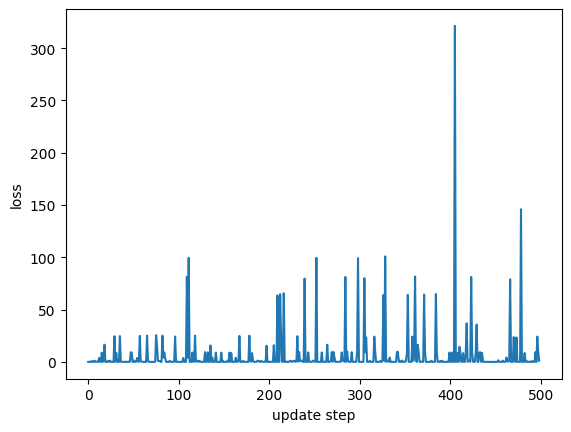

In [136]:
import matplotlib.pyplot as plt
plt.plot(losses)
plt.xlabel("update step")
plt.ylabel("loss")
plt.show()


Move 50: Black (random) plays action 1212


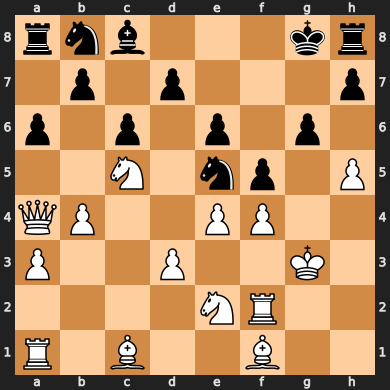

KeyboardInterrupt: 

In [137]:
from IPython.display import display, clear_output
import time

# Play a game with the trained model
viz_env = WrappedEnv()
viz_env.reset()

move_num = 0
while not viz_env.is_done():
    clear_output(wait=True)
    
    # Get current board for display
    state = torch.tensor(viz_env.state(), dtype=torch.float32).unsqueeze(0)
    mask = viz_env.get_legal_actions().unsqueeze(0)
    board = board_from_shaped_observation(state.squeeze(0), viz_env.get_current_player())
    
    # White move (trained model)
    if viz_env.get_current_player() == 0:
        with torch.no_grad():
            logits = model_1_a(state, mask)
        action = torch.argmax(logits, dim=1).item()
        print(f"Move {move_num}: White (model) plays action {action}")
    else:
        # Black move (random)
        legal = mask.squeeze(0).nonzero().squeeze(1).tolist()
        action = random.choice(legal)
        print(f"Move {move_num}: Black (random) plays action {action}")
    
    display(board)
    viz_env.step([action])
    move_num += 1
    time.sleep(1)  # pause to see each move

# Show final board
clear_output(wait=True)
final_board = board_from_shaped_observation(
    torch.tensor(viz_env.state(), dtype=torch.float32) if not viz_env.is_done() 
    else state.squeeze(0), 
    0
)
print(f"Game over after {move_num} moves!")
display(final_board)

In [ ]:
from model.chess_model import ChessPolicyProbs
from torch.distributions import Categorical
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.nn.functional import mse_loss
white_model = ChessPolicyProbs()
black_model = ChessPolicyProbs()


In [ ]:
def model_acc(model, envs):
    values, log_probs, entropies = [], [], []
    state = envs.get_current_states()
    prob_dist, value = model(state, envs.get_current_actions())
    actions = torch.multinomial(prob_dist, num_samples=1)
    envs.move(actions)
    dist = Categorical(probs=prob_dist)
    values.append(value)
    log_probs.append(torch.log(prob_dist.gather(1, actions)))
    entropies.append(dist.entropy())
    return values, log_probs, entropies, state,actions

def backpropagate(model, envs, optimizer, rewards, log_probs, values, entropies, state, actions):
    with torch.no_grad():
        _, bootstrap_value = model(state, actions)
        R = bootstrap_value * (1 - envs.get_done().int().unsqueeze(1))

    actor_loss, critic_loss = 0,0
    for i in reversed(range(len(rewards))):
      R = rewards[i].unsqueeze(1) + 0.99 * R
      advantage = R - values[i]
      actor_loss -= log_probs[i] * advantage.detach()
      critic_loss += mse_loss(values[i], R.detach())
    loss = actor_loss.mean() + critic_loss.mean() - 0.001 * torch.stack(entropies).mean()
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(
      list(model.parameters()), 
      max_norm=0.5
    )   
    optimizer.step()
    return loss

100%|██████████| 1999/1999 [5:41:57<00:00, 10.26s/it, loss=1.04, mem=0]        


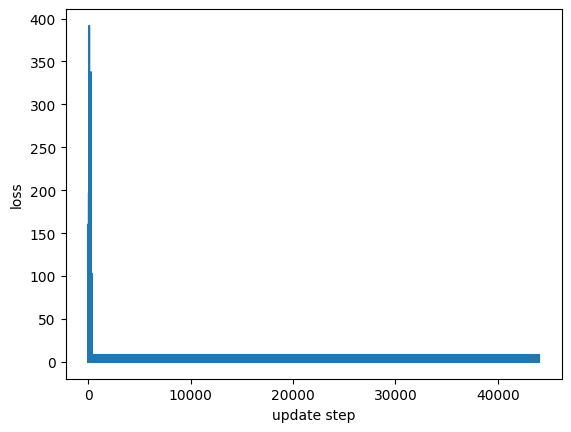

In [24]:
envs = EnvSpawner(8)
envs.reset_all()
optimizer_white = torch.optim.Adam(
    list(white_model.parameters()), lr=0.2
)
optimizer_black = torch.optim.Adam(
    list(black_model.parameters()), lr=0.2
)
pbar = tqdm(range(1,2000))
losses = []
for episode in pbar:
  for _ in range(50):
    values_white, log_probs_white, entropies_white, state_white, actions_white = model_acc(white_model, envs)
    values_black, log_probs_black, entropies_black, state_black, actions_black = model_acc(black_model, envs)
    rewards_white_list,rewards_black_list = [],[]
    rewards_white = envs.get_rewards('white') -0.01
    rewards_black = envs.get_rewards('black') -0.01
    for i, env in enumerate(envs.envs):
      if env.is_done():
        if env.env.get_time_step().rewards[0] == 1:
          rewards_white[i] += 2
          rewards_black[i] -= 2
        else:
          rewards_white[i] -= 2
          rewards_black[i] += 2
        
    rewards_white_list.append(rewards_white)
    rewards_black_list.append(rewards_black)
    if any(envs.get_done()):
      envs.reset_all()
      break
    loss_1 = backpropagate(white_model, envs, optimizer_white, rewards_white_list, log_probs_white, values_white, entropies_white, state_white, actions_white)
    loss_2 = backpropagate(black_model, envs, optimizer_black, rewards_black_list, log_probs_black, values_black, entropies_black, state_black, actions_black)
    losses.append(loss_1.item() + loss_2.item())
    pbar.set_postfix(loss=loss_1.item(), mem=envs.buffers[0].index)
    if episode % 20 == 0:
      optimizer_white.param_groups[0]['lr'] *= 0.5
      optimizer_black.param_groups[0]['lr'] *= 0.5

plt.plot(losses)
plt.xlabel("update step")
plt.ylabel("loss")
plt.show()


Game over after 45 moves!


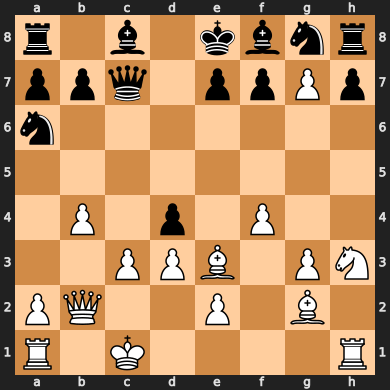

In [ ]:
from IPython.display import display, clear_output
import time
white_modes = load_white_model()

# Play a game with the trained model
viz_env = WrappedEnv()
viz_env.reset()

move_num = 0
while not viz_env.is_done():
    clear_output(wait=True)
    
    # Get current board for display
    state = torch.tensor(viz_env.state(), dtype=torch.float32).unsqueeze(0)
    mask = viz_env.get_legal_actions().unsqueeze(0)
    board = board_from_shaped_observation(state.squeeze(0), viz_env.get_current_player())
    
    # White move (trained model)
    if viz_env.get_current_player() == 0:
        prob_dist,_ = white_model(state, mask)
        action = torch.multinomial(prob_dist, num_samples=1)
        print(f"Move {move_num}: White (model) plays action {action}")
    else:
        # Black move (random)
        prob_dist,_ = black_model(state, mask)
        action = torch.multinomial(prob_dist, num_samples=1)
        print(f"Move {move_num}: Black (random) plays action {action}")
    
    display(board)
    viz_env.step([action])
    move_num += 1
    time.sleep(0.4)  # pause to see each move

# Show final board
clear_output(wait=True)
final_board = board_from_shaped_observation(
    torch.tensor(viz_env.state(), dtype=torch.float32) if not viz_env.is_done() 
    else state.squeeze(0), 
    0
)
print(f"Game over after {move_num} moves!")
display(final_board)